
 DATASET SHAPE: (90, 18)

 DATA TYPES:
 FlightNumber        int64
Date                  str
BoosterVersion        str
PayloadMass       float64
Orbit                 str
LaunchSite            str
Outcome               str
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad            str
Block             float64
ReusedCount         int64
Serial                str
Longitude         float64
Latitude          float64
Class               int64
dtype: object

 MISSING VALUES:
 FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

 DUPLICATES: 0

 After preprocessing shape: (90, 25)

 STATISTICAL

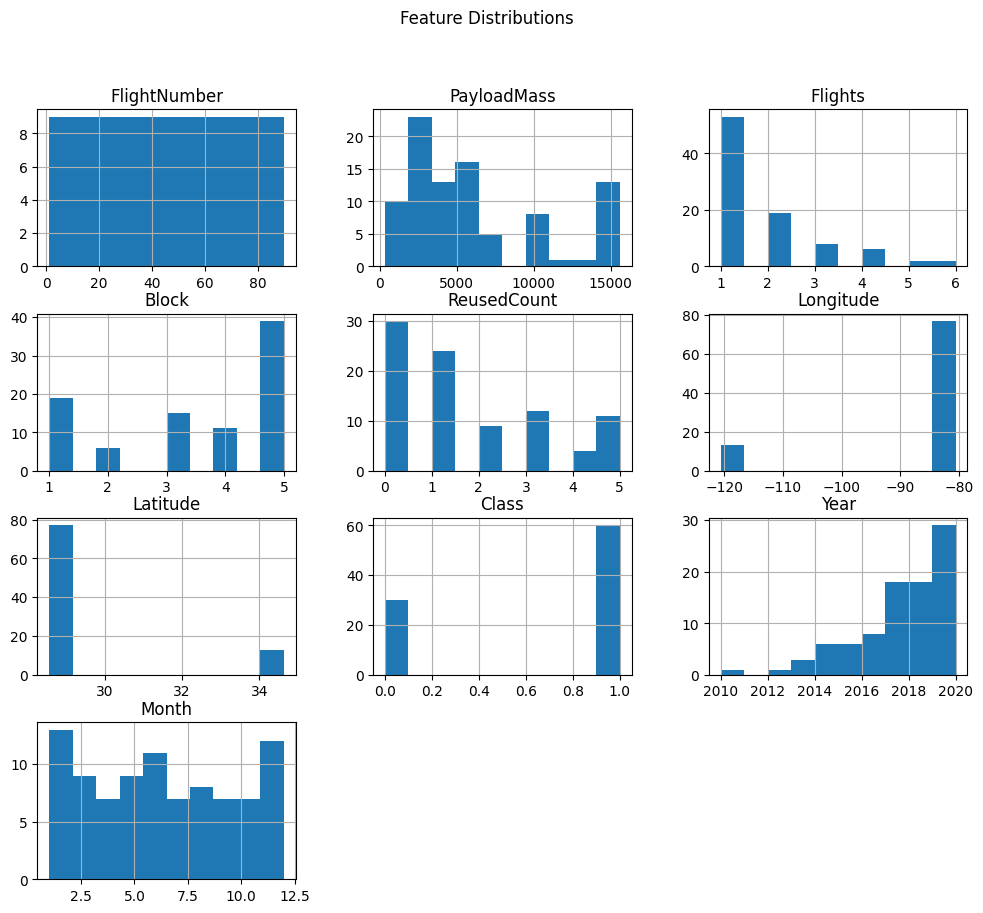

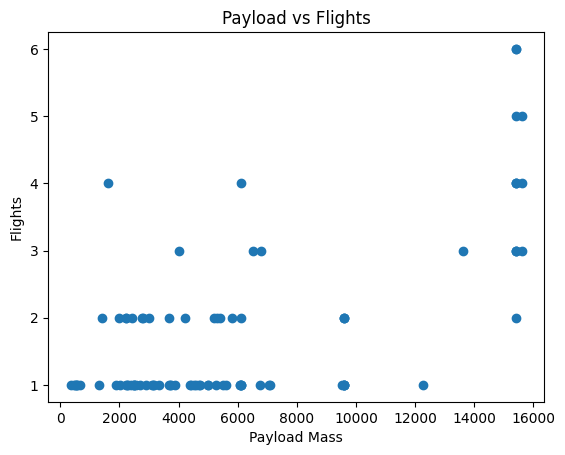

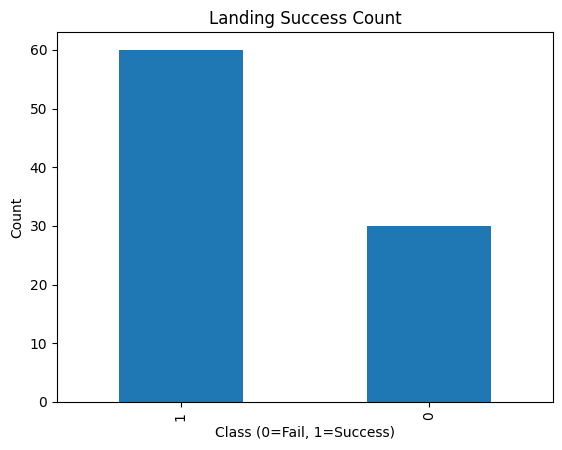


 Logistic Regression Accuracy: 0.8888888888888888
 Random Forest Accuracy: 0.9444444444444444

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.86      0.92        14

    accuracy                           0.89        18
   macro avg       0.83      0.93      0.86        18
weighted avg       0.93      0.89      0.90        18


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.93      0.96        14

    accuracy                           0.94        18
   macro avg       0.90      0.96      0.93        18
weighted avg       0.96      0.94      0.95        18


Confusion Matrix (Random Forest):
 [[ 4  0]
 [ 1 13]]


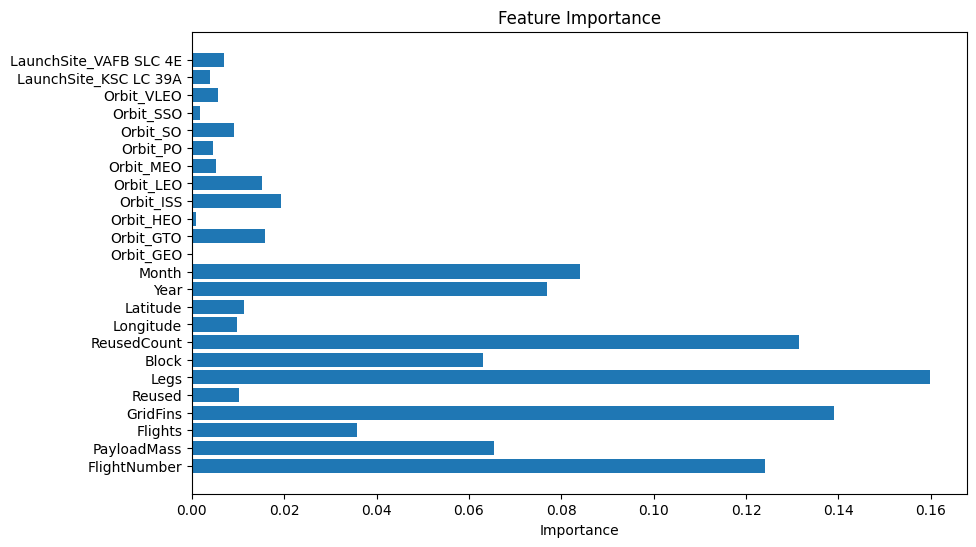


 Model saved successfully!

 Features saved successfully!


In [ ]:
# FALCON 9 LANDING SUCCESS PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

# DATASET LOADING & UNDERSTANDING

df = pd.read_csv("dataset_part_2.csv")

print("\n DATASET SHAPE:", df.shape)
print("\n DATA TYPES:\n", df.dtypes)
print("\n MISSING VALUES:\n", df.isnull().sum())
print("\n DUPLICATES:", df.duplicated().sum())


# DATA PREPROCESSING

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop unnecessary columns
df.drop(['Date', 'LandingPad', 'Serial', 'Outcome'], axis=1, inplace=True)

# Encoding categorical features
df = pd.get_dummies(df, drop_first=True)

print("\n After preprocessing shape:", df.shape)


# BASIC STATISTICS
print("\n STATISTICAL SUMMARY:\n", df.describe())


# VISUALIZATION

df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

plt.scatter(df['PayloadMass'], df['Flights'])
plt.xlabel("Payload Mass")
plt.ylabel("Flights")
plt.title("Payload vs Flights")
plt.show()

df['Class'].value_counts().plot(kind='bar')
plt.title("Landing Success Count")
plt.xlabel("Class (0=Fail, 1=Success)")
plt.ylabel("Count")
plt.show()


# FEATURE & TARGET
X = df.drop("Class", axis=1)
y = df["Class"]


# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# MODEL IMPLEMENTATION

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# EVALUATION

print("\n Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(" Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest):\n", confusion_matrix(y_test, y_pred_rf))


# FEATURE IMPORTANCE
importances = rf.feature_importances_
feat_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feat_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()


# MODEL SAVING
joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

# ADDED PART: SAVE FEATURES FOR STREAMLIT
joblib.dump(list(X.columns), "features.pkl")

print("\n Model saved successfully!")
print("\n Features saved successfully!")